# Corrected Silent Lifecycle Visual After GAD Reclassification

This notebook loads the corrected data from `09_rq1_gad_reclassification_intermediate.ipynb` and redraws the silent lifecycle visual after merging GAD-ending transparent patterns into S1/S2/S3.


In [1]:
import contextlib
import io
import json
from pathlib import Path

NOTEBOOK_09_PATH = Path('09_rq1_gad_reclassification_intermediate.ipynb')
nb09 = json.loads(NOTEBOOK_09_PATH.read_text())

with contextlib.redirect_stdout(io.StringIO()):
    for i, cell in enumerate(nb09['cells']):
        if cell.get('cell_type') == 'code':
            source = ''.join(cell.get('source', []))
            exec(compile(source, f'corrected_gad_cell_{i}', 'exec'), globals())

print('Loaded corrected GAD reclassification data.')
print('Corrected silent rows:', len(corrected_silent_order_df))
print('Corrected transparent rows:', len(corrected_transparent_order_df))

Loaded corrected GAD reclassification data.
Corrected silent rows: 332
Corrected transparent rows: 261


## Visual: Corrected Stage-Aligned Boxplots with Rounded Local Axes


Excluded from visual because n < 2:


,Pattern,Severity,n
0,S1,Unknown,1
1,S2,Critical,1
2,S3,Critical,1
3,S3,Low,1


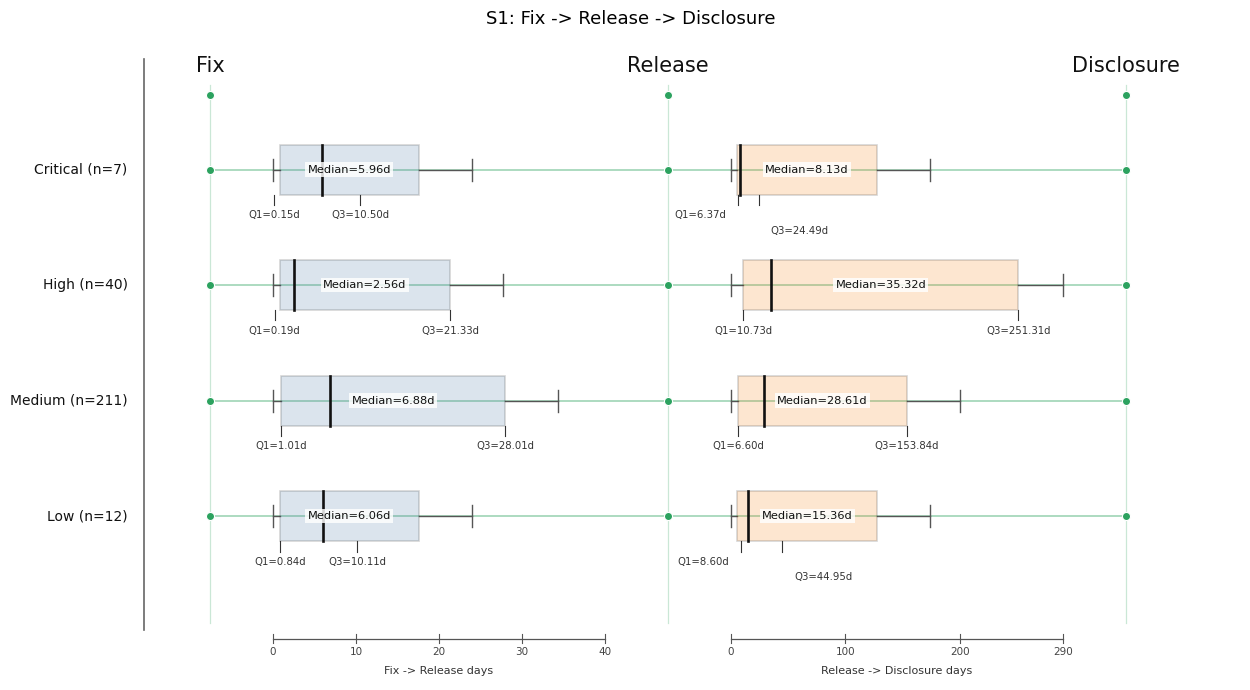

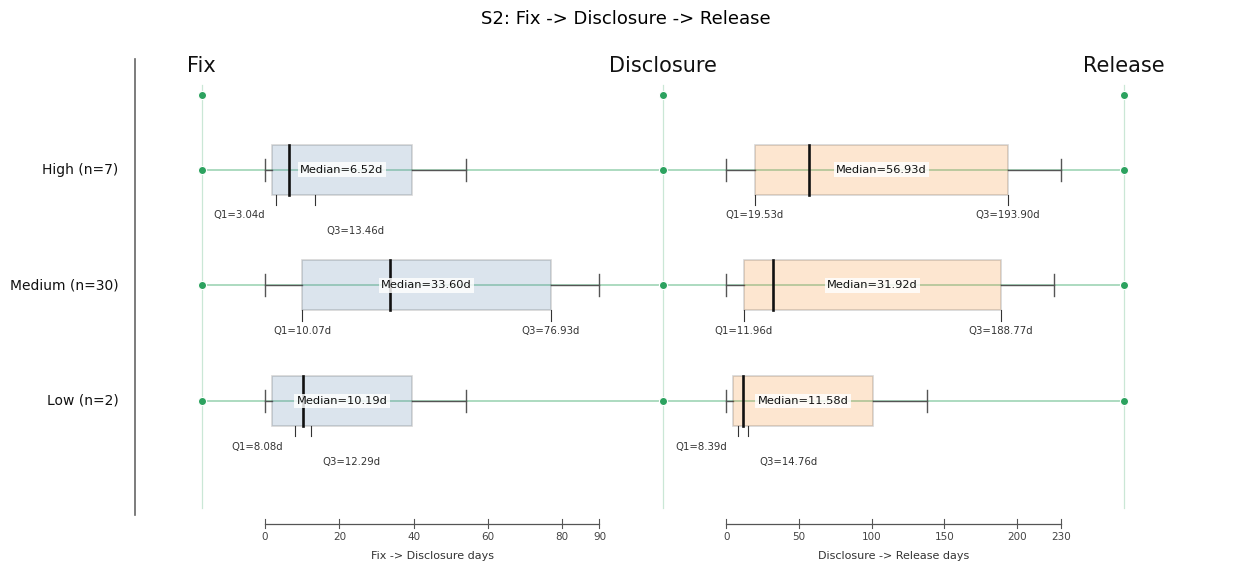

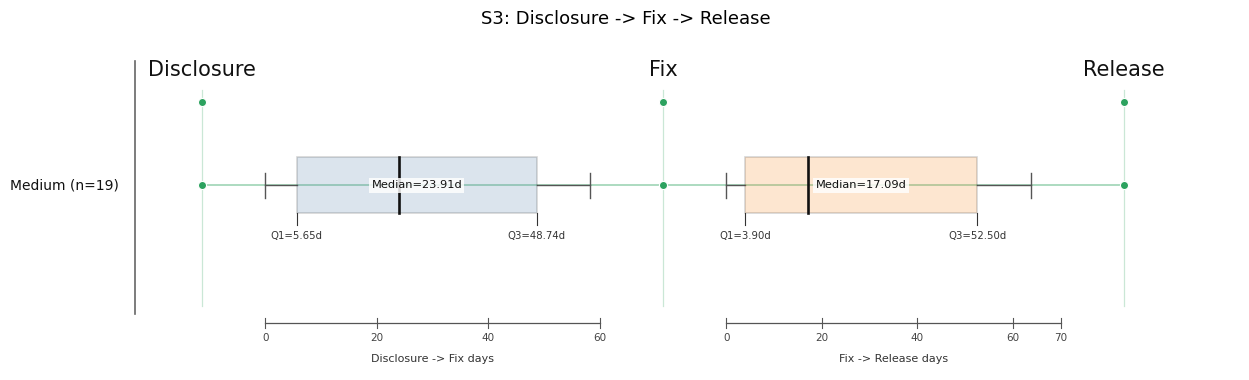

In [2]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import numpy as np

transition_pattern_titles = {
    'S1': 'S1: Fix -> Release -> Disclosure',
    'S2': 'S2: Fix -> Disclosure -> Release',
    'S3': 'S3: Disclosure -> Fix -> Release',
}
severity_levels = severity_order
minimum_plot_samples = 2


def pattern_severity_counts(df):
    count_df = (
        df
        .groupby(['Pattern', 'Severity'])
        .size()
        .rename('n')
        .reset_index()
    )
    severity_rank = {severity: index for index, severity in enumerate(severity_levels)}
    count_df['Severity rank'] = count_df['Severity'].map(severity_rank).fillna(99)
    return count_df.sort_values(['Pattern', 'Severity rank']).drop(columns='Severity rank')


corrected_silent_visual_sample_counts = pattern_severity_counts(corrected_silent_order_df)
corrected_silent_visual_excluded_groups = corrected_silent_visual_sample_counts[
    corrected_silent_visual_sample_counts['n'].lt(minimum_plot_samples)
].copy()

print(f'Excluded from visual because n < {minimum_plot_samples}:')
if corrected_silent_visual_excluded_groups.empty:
    print('None')
else:
    display(corrected_silent_visual_excluded_groups.reset_index(drop=True))

def round_up_to_10(value):
    if pd.isna(value) or value <= 0:
        return 10
    return int(np.ceil(value / 10) * 10)


def transition_stats(values):
    values = values.dropna()
    return {
        'n': len(values),
        'q1': values.quantile(0.25),
        'median': values.median(),
        'q3': values.quantile(0.75),
    }


def summary_axis_max(pattern_df, duration_column):
    rows = []
    for severity, group in pattern_df.groupby('Severity'):
        stats = transition_stats(group[duration_column])
        rows.append(stats)

    stats_df = pd.DataFrame(rows)
    if stats_df.empty:
        return 10

    # Use groups with n>1 when available, so single extreme categories do not shrink all boxes.
    base_df = stats_df[stats_df['n'].gt(1)].copy()
    if base_df.empty:
        base_df = stats_df

    visible_max = max(base_df['q3'].max(), base_df['median'].max())
    return round_up_to_10(visible_max * 1.15)


def local_axis_position_linear(value, start_x, end_x, axis_max):
    if pd.isna(value) or axis_max <= 0:
        return start_x
    fraction = min(max(value / axis_max, 0), 1)
    return start_x + fraction * (end_x - start_x)


def rounded_tick_values(axis_max):
    if axis_max <= 40:
        step = 10
    elif axis_max <= 100:
        step = 20
    elif axis_max <= 250:
        step = 50
    elif axis_max <= 500:
        step = 100
    else:
        step = 200

    ticks = list(range(0, int(axis_max) + 1, step))
    if ticks[-1] != axis_max:
        ticks.append(axis_max)
    return sorted(set(ticks))


def draw_rounded_local_axis(ax, start_x, end_x, y, axis_max, label):
    ax.plot([start_x, end_x], [y, y], color='#555555', linewidth=0.9, zorder=1)

    for tick_value in rounded_tick_values(axis_max):
        tick_x = local_axis_position_linear(tick_value, start_x, end_x, axis_max)
        ax.plot([tick_x, tick_x], [y - 0.05, y + 0.05], color='#555555', linewidth=0.8, zorder=1)
        ax.text(
            tick_x,
            y - 0.10,
            f'{tick_value}',
            ha='center',
            va='top',
            fontsize=7.5,
            color='#444444',
        )

    ax.text(
        (start_x + end_x) / 2,
        y - 0.32,
        f'{label} days',
        ha='center',
        va='top',
        fontsize=8,
        color='#333333',
    )


def draw_readable_boxplot_on_axis(ax, start_x, end_x, y, height, values, color, axis_max):
    stats = transition_stats(values)
    q1_x = local_axis_position_linear(stats['q1'], start_x, end_x, axis_max)
    median_x = local_axis_position_linear(stats['median'], start_x, end_x, axis_max)
    q3_x = local_axis_position_linear(stats['q3'], start_x, end_x, axis_max)

    axis_width = end_x - start_x
    min_box_width = axis_width * 0.42
    raw_left = min(q1_x, q3_x)
    raw_right = max(q1_x, q3_x)
    raw_width = raw_right - raw_left

    if raw_width < min_box_width:
        center_x = median_x
        left_x = center_x - min_box_width / 2
        right_x = center_x + min_box_width / 2
    else:
        left_x = raw_left
        right_x = raw_right

    left_x = max(left_x, start_x + axis_width * 0.02)
    right_x = min(right_x, end_x - axis_width * 0.02)
    if right_x - left_x < min_box_width:
        if left_x <= start_x + axis_width * 0.02:
            right_x = left_x + min_box_width
        else:
            left_x = right_x - min_box_width

    box = Rectangle(
        (left_x, y - height / 2),
        right_x - left_x,
        height,
        facecolor=color,
        edgecolor='#333333',
        linewidth=1.2,
        alpha=0.20,
        zorder=3,
    )
    ax.add_patch(box)

    median_x = min(max(median_x, left_x), right_x)
    ax.plot(
        [median_x, median_x],
        [y - height / 2, y + height / 2],
        color='#111111',
        linewidth=1.9,
        zorder=4,
    )

    whisker_left = max(start_x, left_x - axis_width * 0.16)
    whisker_right = min(end_x, right_x + axis_width * 0.16)
    ax.plot([whisker_left, left_x], [y, y], color='#555555', linewidth=1.0, zorder=2)
    ax.plot([right_x, whisker_right], [y, y], color='#555555', linewidth=1.0, zorder=2)
    ax.plot([whisker_left, whisker_left], [y - height * 0.22, y + height * 0.22], color='#555555', linewidth=1.0, zorder=2)
    ax.plot([whisker_right, whisker_right], [y - height * 0.22, y + height * 0.22], color='#555555', linewidth=1.0, zorder=2)

    ax.text(
        (left_x + right_x) / 2,
        y,
        f'Median={stats["median"]:.2f}d',
        ha='center',
        va='center',
        fontsize=8.2,
        color='#111111',
        bbox={
            'facecolor': 'white',
            'edgecolor': 'none',
            'alpha': 0.82,
            'pad': 1.6,
        },
        zorder=6,
    )

    # Q1 and Q3 are labeled outside the box at their mapped positions on the transition axis.
    # When Q1 and Q3 are close, stagger and nudge labels so both remain readable.
    ax.plot([q1_x, q1_x], [y - height / 2, y - height / 2 - 0.12], color='#333333', linewidth=0.8, zorder=4)
    ax.plot([q3_x, q3_x], [y - height / 2, y - height / 2 - 0.12], color='#333333', linewidth=0.8, zorder=4)

    label_base_y = y - height / 2 - 0.18
    close_labels = abs(q3_x - q1_x) < axis_width * 0.18
    if close_labels:
        q1_label_x = q1_x - axis_width * 0.035
        q3_label_x = q3_x + axis_width * 0.035
        q1_label_y = label_base_y
        q3_label_y = label_base_y - 0.18
        q1_ha = 'right'
        q3_ha = 'left'
    else:
        q1_label_x = q1_x
        q3_label_x = q3_x
        q1_label_y = label_base_y
        q3_label_y = label_base_y
        q1_ha = 'center'
        q3_ha = 'center'

    ax.text(
        q1_label_x,
        q1_label_y,
        f'Q1={stats["q1"]:.2f}d',
        ha=q1_ha,
        va='top',
        fontsize=7.3,
        color='#333333',
        bbox={
            'facecolor': 'white',
            'edgecolor': 'none',
            'alpha': 0.86,
            'pad': 0.9,
        },
        zorder=6,
    )
    ax.text(
        q3_label_x,
        q3_label_y,
        f'Q3={stats["q3"]:.2f}d',
        ha=q3_ha,
        va='top',
        fontsize=7.3,
        color='#333333',
        bbox={
            'facecolor': 'white',
            'edgecolor': 'none',
            'alpha': 0.86,
            'pad': 0.9,
        },
        zorder=6,
    )


def plot_stage_aligned_fixed_boxes_with_axes(pattern):
    pattern_df = corrected_silent_order_df[corrected_silent_order_df['Pattern'].eq(pattern)].copy()
    stages = [
        pattern_df['First'].iloc[0],
        pattern_df['Second'].iloc[0],
        pattern_df['Third'].iloc[0],
    ]
    severity_counts = pattern_df['Severity'].value_counts().to_dict()
    present_severities = [
        severity for severity in severity_levels
        if severity_counts.get(severity, 0) >= minimum_plot_samples
    ]
    pattern_df = pattern_df[pattern_df['Severity'].isin(present_severities)].copy()

    if not present_severities:
        print(f'Skipping {pattern}: no severity groups with n >= {minimum_plot_samples}.')
        return

    first_axis_max = summary_axis_max(pattern_df, 'Days: First -> Second')
    second_axis_max = summary_axis_max(pattern_df, 'Days: Second -> Third')

    row_gap = 1.34
    bottom_row_y = 1.72
    y_positions = {
        severity: bottom_row_y + row_gap * (len(present_severities) - index - 1)
        for index, severity in enumerate(present_severities)
    }

    fig_height = max(3.9, 1.15 * len(present_severities) + 2.4)
    fig, ax = plt.subplots(figsize=(12.8, fig_height))

    stage_x = [1.0, 5.0, 9.0]
    first_axis = (stage_x[0] + 0.55, stage_x[1] - 0.55)
    second_axis = (stage_x[1] + 0.55, stage_x[2] - 0.55)

    header_y = max(y_positions.values()) + 1.08
    axis_y = 0.30
    guide_color = '#2ca25f'

    for x, stage in zip(stage_x, stages):
        ax.text(
            x,
            header_y,
            stage,
            ha='center',
            va='bottom',
            fontsize=15,
            color='#111111',
        )
        ax.plot([x, x], [axis_y + 0.18, header_y - 0.10], color=guide_color, linewidth=0.9, alpha=0.25, zorder=0)
        ax.scatter([x], [header_y - 0.22], s=34, color=guide_color, edgecolor='white', linewidth=0.8, zorder=5)

    draw_rounded_local_axis(
        ax, first_axis[0], first_axis[1], axis_y, first_axis_max, f'{stages[0]} -> {stages[1]}'
    )
    draw_rounded_local_axis(
        ax, second_axis[0], second_axis[1], axis_y, second_axis_max, f'{stages[1]} -> {stages[2]}'
    )

    for severity in present_severities:
        severity_df = pattern_df[pattern_df['Severity'].eq(severity)].copy()
        y = y_positions[severity]

        ax.plot(stage_x, [y] * len(stage_x), color=guide_color, linewidth=1.1, alpha=0.50, zorder=1)
        ax.scatter(stage_x, [y] * len(stage_x), s=34, color=guide_color, edgecolor='white', linewidth=0.8, zorder=5)

        draw_readable_boxplot_on_axis(
            ax, first_axis[0], first_axis[1], y, 0.58, severity_df['Days: First -> Second'], '#4c78a8', first_axis_max
        )
        draw_readable_boxplot_on_axis(
            ax, second_axis[0], second_axis[1], y, 0.58, severity_df['Days: Second -> Third'], '#f58518', second_axis_max
        )

        ax.text(
            0.28,
            y,
            f'{severity} (n={severity_counts[severity]})',
            ha='right',
            va='center',
            fontsize=10,
            color='#111111',
        )

    ax.plot([0.42, 0.42], [axis_y + 0.10, header_y + 0.2], color='#666666', linewidth=1.2)
    ax.set_xlim(-0.65, 10.0)
    ax.set_ylim(-0.18, header_y + 0.35)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.set_title(transition_pattern_titles[pattern], fontsize=13, pad=16)
    fig.tight_layout()
    plt.show()
    plt.close(fig)


for pattern in ['S1', 'S2', 'S3']:
    plot_stage_aligned_fixed_boxes_with_axes(pattern)